# Sección 1

**Veasé el readme para detalle**

Bateria de Vanadio. En base a esta sección se buscará implementar condiciones de borde del tipo 0D para el modelado de celda + tanques que es de tipo 1D.

### Definimos parámetros necesarios

In [9]:
params = {
    # Constantes
    "F": 96485.33212,   # C/mol
    "n": 1,             # e– por reacción V(II)/V(III) y V(IV)/V(V)

    # Geometría/hidráulica (tanques iguales por ahora)
    "V_t_an": 0.003,   # m^3  (ánodo)
    "V_t_cat": 0.003,  # m^3  (cátodo)
    "Q_an": 5e-6,     # m^3/s
    "Q_cat": 5e-6,    # m^3/s

    # Corriente/voltaje (modo)
    # --- Galvanostático:
    "I_mode": "galv",   # "galv" o "pot"
    "I0": 10.0,         # A (constante o rampa que definas)
    "I1": 2.0,         # A (si rampa, fin)
    # Tiempo de simulación
    "t_end": 3.65e+4  # s
}

In [10]:
def I_t(t, params):
    I0, I1, t_end = params["I0"], params["I1"], params["t_end"]
    frac = min(max(t / t_end, 0), 1)  # 
    return I0 + (I1 - I0) * frac

In [11]:
params.update({
    # Área de celda
    "A_cell": 0.01,     # m^2

    # Concentraciones de entrada (por defecto = estado del tanque: recirculación perfecta)
    "C_V2_in": None,
    "C_V3_in": None,
    "C_VO2_in": None,
    "C_VO2p_in": None,
})

In [12]:
def anode_tank(t, y, params):
    # Concentraciones del tanque anódico
    C_V2, C_V3 = y
    
    # Parámetros relevantes
    I = params["I"]            # Corriente impuesta [A]
    F = params["F"]            # Constante de Faraday [C/mol]
    Q = params["Q_an"]         # Caudal volumétrico en el ánodo [m³/s]
    V_t = params["V_t_an"]     # Volumen del tanque anódico [m³]

    # Ecuación diferencial para V²⁺: salida por flujo y consumo farádico
    # Término convectivo: (Q/V_t) * (Cm - C)
    # Producción/Consumo Faradico: +- I/(F*V_t)
    dC_V2_dt = (Q/V_t)*(params["C_V2_in"] - C_V2) - I/(F*V_t)
    # Ecuación diferencial para V³⁺: salida por flujo y producción farádica
    dC_V3_dt = (Q/V_t)*(params["C_V3_in"] - C_V3) + I/(F*V_t)

    # Devuelve las derivadas del ánodo
    return [dC_V2_dt, dC_V3_dt]

In [13]:
def cathode_tank(t, y, params):
    # Desempaqueta concentraciones del tanque catódico
    C_VO2, C_VO2p = y
    
    # Extrae parámetros relevantes
    I = params["I"]             # Corriente impuesta [A]
    F = params["F"]             # Constante de Faraday [C/mol]
    Q = params["Q_cat"]         # Caudal volumétrico en el cátodo [m³/s]
    V_t = params["V_t_cat"]     # Volumen del tanque catódico [m³]

    # Ecuación diferencial para VO²⁺: salida por flujo y producción farádica
    dC_VO2_dt  = (Q/V_t)*(params["C_VO2_in"] - C_VO2) + I/(F*V_t)
    # Ecuación diferencial para VO₂⁺: salida por flujo y consumo farádico
    dC_VO2p_dt = (Q/V_t)*(params["C_VO2p_in"] - C_VO2p) - I/(F*V_t)

    # Devuelve las derivadas del cátodo
    return [dC_VO2_dt, dC_VO2p_dt]

In [ ]:
from scipy.integrate import solve_ivp
import numpy as np

# Iniciales (Gandomi 2016)
C0_an = np.array([950.0, 50.0])   # [V2+, V3+]   mol/m^3
C0_cat= np.array([50.0, 950.0])   # [VO2+, VO2+] mol/m^3
y0 = np.r_[C0_an, C0_cat] # Estado inicial del sistema, 4 variables

# Right hand side (RHS) acoplado con recirculación perfecta y corriente en rampa
def rhs(t, y, params):
    # actualizar corriente impuesta (galvanostático con rampa)
    params["I"] = I_t(t, params) # actulizamos la corriente a medida que pasa el tiempo
    # recirculación: C_in = C_tanque
    C_V2, C_V3, C_VO2, C_VO2p = y # Recirculación perfecta
    params["C_V2_in"]   = C_V2
    params["C_V3_in"]   = C_V3
    params["C_VO2_in"]  = C_VO2
    params["C_VO2p_in"] = C_VO2p # asumimos que se mezcla perfectamente
    # derivadas por tanque
    d_an  = anode_tank(t, [C_V2, C_V3], params) # aplicamos funciones de los balances de materia
    # devuelve un vector con dos derivadas
    d_cat = cathode_tank(t, [C_VO2, C_VO2p], params) # devuelve un vector de dos derivadas
    return np.r_[d_an, d_cat] # combinamos todo en un único vector

In [ ]:
# Integramos
t_span = (0.0, params["t_end"])
t_eval = np.linspace(*t_span, 500)
sol = solve_ivp(lambda t,y: rhs(t,y,params), t_span, y0, t_eval=t_eval, method="BDF")

In [ ]:
# Resumen
C_V2, C_V3, C_VO2, C_VO2p = sol.y
print(f"Estados finales (mol/m^3): V2+={C_V2[-1]:.1f}, V3+={C_V3[-1]:.1f}, VO2+={C_VO2[-1]:.1f}, VO2+={C_VO2p[-1]:.1f}")
# SOC (definición simple por par): anodo = V2+/(V2+ + V3+); cátodo = VO2p/(VO2p + VO2)
soc_an  = C_V2 / (C_V2 + C_V3)
soc_cat = C_VO2p / (C_VO2p + C_VO2)
print(f"SOC inicial an/cat: {soc_an[0]:.3f} / {soc_cat[0]:.3f}")
print(f"SOC final   an/cat: {soc_an[-1]:.3f} / {soc_cat[-1]:.3f}")

Estados finales (mol/m^3): V2+=193.4, V3+=806.6, VO2+=806.6, VO2+=193.4
SOC inicial an/cat: 0.950 / 0.950
SOC final   an/cat: 0.193 / 0.193


In [18]:
import matplotlib.pyplot as plt

In [20]:
# Tiempo y SOC
t = sol.t
soc_an  = C_V2 / (C_V2 + C_V3)
soc_cat = C_VO2p / (C_VO2p + C_VO2)

In [ ]:
# Momentos que queremos mostrar
t_points = [0, 2*3600, params["t_end"]]  # 0h, 2h, fin
labels = ["Inicio", "2 h", "Final"]
colors = ["#0077be", "#ffa500", "#d9534f"]  # azul → naranja → rojo

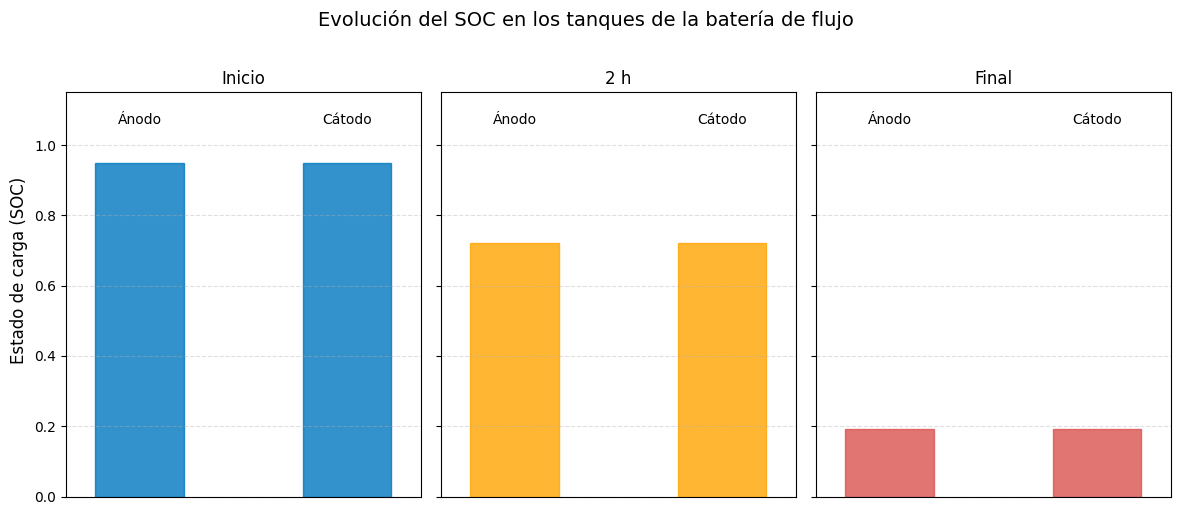

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5), sharey=True)

for ax, tp, lbl, col in zip(axes, t_points, labels, colors):
    idx = np.argmin(np.abs(t - tp))
    h_an, h_cat = soc_an[idx], soc_cat[idx]

    # Dibujar los dos tanques
    ax.add_patch(plt.Rectangle((0, 0), 0.3, h_an, color=col, alpha=0.8))
    ax.add_patch(plt.Rectangle((0.7, 0), 0.3, h_cat, color=col, alpha=0.8))

    # Etiquetas dentro del panel
    ax.text(0.15, 1.05, "Ánodo", ha="center", va="bottom", fontsize=10)
    ax.text(0.85, 1.05, "Cátodo", ha="center", va="bottom", fontsize=10)

    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(0, 1.15)
    ax.set_xticks([])
    ax.set_title(lbl, fontsize=12)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

# --- Ejes y título general ---
fig.supylabel("Estado de carga (SOC)", fontsize=12)
fig.suptitle("Evolución del SOC en los tanques de la batería de flujo", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

